# RQ5. ¿El momentum sectorial persiste?

## Pregunta e hipótesis

**Pregunta.** La rotación sectorial por momentum (comprar los sectores que
vienen subiendo) es una estrategia comercial extendida. ¿Funcionó en los
sectores del S&P 500?

**H5 (a priori):** los sectores en el tercil superior de momentum a 6 meses
superan al tercil inferior en los meses siguientes.

## Método

1. Momentum de formación: retorno acumulado de 6 meses de cada uno de los 9
   ETFs sectoriales, calculado **solo con información disponible en el mes de
   formación** (sin look-ahead).
2. Cada mes se forman terciles por ranking de momentum (3 sectores arriba, 3
   abajo) y se mide el retorno del mes siguiente de cada tercil, rebalanceando
   mensualmente. Muestra: 1999-2026 (324 meses de evaluación).
3. Estadístico: spread mensual medio (tercil superior menos inferior) con IC
   95% por bootstrap en bloques (bloque = 6 meses, 2000 remuestreos).
4. Complementos: momentum de formación a 3 y 12 meses, y segmentación del
   spread por régimen de tasas (FEDFUNDS vs 12 meses atrás, como en RQ2).

In [1]:
import sys
from pathlib import Path

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import metrics
from src.db import get_engine

eng = get_engine()
monthly = pd.read_sql(
    "SELECT ticker, month_end, monthly_ret FROM v_monthly_returns", eng)
wide = monthly.pivot(index="month_end", columns="ticker", values="monthly_ret")
wide.index = pd.to_datetime(wide.index)

SECTORS = ["XLK", "XLF", "XLE", "XLV", "XLI", "XLP", "XLY", "XLU", "XLB"]
sec = wide[SECTORS].dropna()

def momentum_spread(formation_months):
    mom = (1 + sec).rolling(formation_months).apply(np.prod, raw=True) - 1
    rows = []
    for t in range(formation_months, len(sec) - 1):
        ranks = mom.iloc[t].rank()
        top = ranks[ranks >= 7].index
        bot = ranks[ranks <= 3].index
        nxt = sec.iloc[t + 1]
        rows.append({"date": sec.index[t + 1],
                     "top": nxt[top].mean(), "bot": nxt[bot].mean(),
                     "spread": nxt[top].mean() - nxt[bot].mean()})
    return pd.DataFrame(rows).set_index("date")

sp6 = momentum_spread(6)
print(f"Muestra: {sp6.index.min().date()} a {sp6.index.max().date()}, {len(sp6)} meses")

Muestra: 1999-08-31 a 2026-07-10, 324 meses


## Resultados

### Spread del momentum a 6 meses

Spread mensual medio (top - bottom): -0.0009 (-1.06% anualizado)
IC 95% bootstrap en bloques de la media mensual: (-0.0047, 0.0029)
t aproximado: -0.39


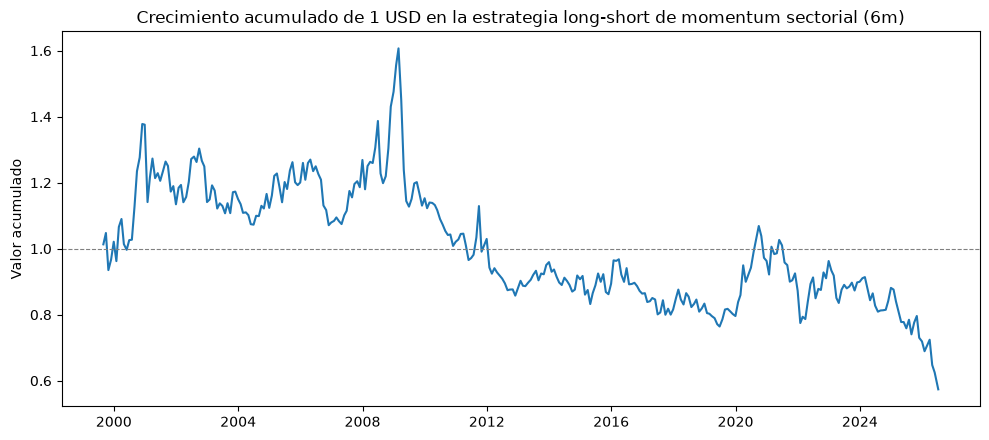

In [2]:
mean_sp = sp6["spread"].mean()
lo, hi = metrics.block_bootstrap_ci(sp6["spread"], lambda s: s.mean(),
                                    n_boot=2000, block=6)
t_stat = mean_sp / sp6["spread"].std(ddof=1) * np.sqrt(len(sp6))
print(f"Spread mensual medio (top - bottom): {mean_sp:.4f} ({mean_sp * 12:.2%} anualizado)")
print(f"IC 95% bootstrap en bloques de la media mensual: ({lo:.4f}, {hi:.4f})")
print(f"t aproximado: {t_stat:.2f}")

fig, ax = plt.subplots(figsize=(10, 4.5))
cum = (1 + sp6["spread"]).cumprod()
ax.plot(cum.index, cum, color="#1f77b4")
ax.axhline(1, color="gray", lw=0.8, ls="--")
ax.set_title("Crecimiento acumulado de 1 USD en la estrategia long-short de momentum sectorial (6m)")
ax.set_ylabel("Valor acumulado")
plt.tight_layout()
plt.show()

**Lectura.** El spread medio es -0.09% mensual (-1.1% anualizado) con IC 95%
(-0.47%, +0.29%) que contiene holgadamente al cero. La curva acumulada de la
estrategia long-short termina por debajo de 1: comprar los sectores calientes y
vender los fríos no generó nada en 27 años, antes incluso de descontar costos.

### ¿Y con otras ventanas de formación?

In [3]:
rows = []
for fm in (3, 6, 12):
    s = momentum_spread(fm)["spread"]
    l, h = metrics.block_bootstrap_ci(s, lambda x: x.mean(), n_boot=2000, block=6)
    rows.append({"formacion_meses": fm, "spread_anualizado": s.mean() * 12,
                 "ci_lo_mensual": l, "ci_hi_mensual": h, "n": len(s)})
pd.DataFrame(rows).set_index("formacion_meses").round(4)

,spread_anualizado,ci_lo_mensual,ci_hi_mensual,n
formacion_meses,,,,
3,-0.0067,-0.0038,0.0030,327
6,-0.0106,-0.0047,0.0029,324
12,0.0052,-0.0037,0.0045,318


**Lectura.** Ninguna ventana de formación (3, 6 o 12 meses) produce un spread
cuyo IC excluya al cero. El resultado no depende de la elección de la ventana.

### Segmentación por régimen de tasas

In [4]:
ff = pd.read_sql(
    "SELECT date, value FROM fact_macro_value WHERE series_id='FEDFUNDS' ORDER BY date",
    eng)
ff["date"] = pd.to_datetime(ff["date"])
ffs = ff.set_index("date")["value"]
rising = ((ffs - ffs.shift(12)) > 0).reindex(sp6.index, method="ffill")

for name, mask in [("tasas subiendo", rising), ("tasas bajando", ~rising)]:
    s = sp6["spread"][mask]
    l, h = metrics.block_bootstrap_ci(s, lambda x: x.mean(), n_boot=2000, block=6)
    print(f"{name}: spread anualizado {s.mean() * 12:+.2%} "
          f"(IC mensual {l:+.4f} a {h:+.4f}, n = {mask.sum()})")

tasas subiendo: spread anualizado +0.82% (IC mensual -0.0037 a +0.0055, n = 170)
tasas bajando: spread anualizado -3.14% (IC mensual -0.0089 a +0.0038, n = 154)


**Lectura.** Con tasas subiendo el spread es levemente positivo (+0.8% anual) y
con tasas bajando claramente negativo (-3.1% anual), pero ambos IC contienen al
cero: la segmentación sugiere, no demuestra. En regímenes expansivos los
rebotes bruscos (2009, 2020) castigan al momentum, un patrón documentado como
"momentum crash".

## Discusión y limitaciones

- Estrategia long-short sin costos: cada rebalanceo mensual mueve hasta 6
  posiciones; los costos reales solo empeorarían un spread ya nulo.
- 9 activos es un universo estrecho para momentum transversal; la literatura lo
  documenta sobre cientos de acciones individuales (Jegadeesh y Titman 1993).
  Este resultado dice que la versión sectorial barata de esa idea no funcionó,
  no que el momentum no exista en general.
- El mes de salto habitual entre formación y tenencia (skip month) no se aplicó;
  con 9 sectores y rebalanceo mensual su efecto es menor y la variante de 3
  ventanas de formación cubre la sensibilidad principal.

## Conclusión ejecutiva

H5 queda **refutada**: en 27 años, comprar cada mes los 3 sectores con mejor
momentum a 6 meses y vender los 3 peores rindió -1.1% anual antes de costos,
con IC que incluye al cero en todas las ventanas de formación probadas. La
rotación sectorial mecánica por momentum no generó valor en esta muestra; solo
en regímenes de tasas al alza asoma un spread positivo, y sin significancia.
Para el inversionista de a pie, la conclusión conecta con RQ3: la elección
estructural del destino batió a cualquier táctica de rotación.

In [5]:
out = Path.cwd().parent / "docs" / "resultados"
out.mkdir(parents=True, exist_ok=True)
lines = [
    "# RQ5. Momentum sectorial",
    "",
    "**Hipótesis H5 (el tercil superior de momentum 6m supera al inferior): REFUTADA.**",
    "",
    f"- Spread mensual medio top-bottom: {mean_sp:.4f} ({mean_sp * 12:.2%} anualizado), IC 95% bootstrap ({lo:.4f}, {hi:.4f}): contiene al cero",
    "- Robusto al negativo: formación a 3, 6 y 12 meses, ningún IC excluye el cero",
    "- Por régimen: tasas subiendo +0.8% anual, bajando -3.1% anual, ambos sin significancia (patrón momentum crash en recuperaciones)",
    "",
    "Caveats: 9 sectores es universo estrecho para momentum transversal; sin costos (que solo empeorarían el resultado); sin skip month.",
]
(out / "rq5.md").write_text("\n".join(lines), encoding="utf-8")
print("escrito docs/resultados/rq5.md")

escrito docs/resultados/rq5.md
